# Mirage-19 Traffic Classification with 1D-CNN

This notebook implements a deep learning pipeline to classify mobile application traffic using the **Mirage-19** dataset. 

## Project Overview
- **Goal**: Classify mobile apps based on the first 36 packets of a flow.
- **Input**: Sequence of 36 packets with 4 features (Direction, Payload Length, TCP Window, Inter-Arrival Time).
- **Model**: 1D Convolutional Neural Network (1D-CNN) implemented in PyTorch.
- **Hardware**: Optimized for execution on GPU (RTX 3070Ti).


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter
import time
import copy

# Configuration
DATA_PATH = "dataset/mirage2019_LOPEZ_lopez_lopez_36P_4F_APP_xST_PAD_metadata.pickle"
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 1e-3
PATIENCE = 12 # Early stopping patience
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RANDOM_SEED = 2025

print(f"Using device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set random seeds for reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti


## Load Data
Loading the preprocessed pickle file containing biflows and labels.

In [18]:
print("Loading dataset...")
with open(DATA_PATH, "rb") as f:
    X_raw = np.array(pickle.load(f), dtype=np.float32) # Convert to numpy array
    y_raw = np.array(pickle.load(f)) # Convert to numpy array

print(f"Data shape: {X_raw.shape}")
print(f"Labels shape: {len(y_raw)}")

# Example sample
print("\nExample Sample (First 5 packets):\n", X_raw[7000][:36])
print("Example Label:", y_raw[7000])


Loading dataset...


C:\Users\Matte\AppData\Local\Temp\ipykernel_2544\2696288309.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  X_raw = np.array(pickle.load(f), dtype=np.float32) # Convert to numpy array


Data shape: (96999, 36, 4)
Labels shape: 96999

Example Sample (First 5 packets):
 [[0.0000000e+00 2.0300000e+02 3.4300000e+02 0.0000000e+00]
 [1.0000000e+00 1.4480000e+03 2.3500000e+02 2.9068947e-02]
 [1.0000000e+00 1.4480000e+03 2.3500000e+02 5.9604645e-06]
 [1.0000000e+00 1.2000000e+03 2.3500000e+02 4.0531158e-06]
 [1.0000000e+00 1.4480000e+03 2.3500000e+02 1.1920929e-05]
 [1.0000000e+00 1.4480000e+03 2.3500000e+02 3.0961990e-02]
 [1.0000000e+00 6.1100000e+02 2.3500000e+02 9.8896027e-04]
 [0.0000000e+00 1.2600000e+02 4.1100000e+02 2.3954153e-02]
 [1.0000000e+00 2.5800000e+02 2.3500000e+02 4.5009851e-02]
 [0.0000000e+00 4.4900000e+02 4.1100000e+02 2.4299002e-01]
 [1.0000000e+00 1.4480000e+03 2.4300000e+02 3.8870096e-02]
 [1.0000000e+00 1.4480000e+03 2.4300000e+02 5.9604645e-06]
 [1.0000000e+00 1.4480000e+03 2.4300000e+02 5.9909821e-03]
 [1.0000000e+00 1.4480000e+03 2.4300000e+02 5.0067902e-06]
 [1.0000000e+00 1.4480000e+03 2.4300000e+02 5.9909821e-03]
 [1.0000000e+00 1.4480000e+03 2.

## Labelling Encoding

In [3]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES}")
print("Classes:", le.classes_)

Number of classes: 40
Classes: ['8 Ball Pool' 'AccuWeather' 'Amazon' 'Booking' 'Comics' 'Diretta'
 'Dropbox' 'Duolingo' 'Facebook' 'Flipboard' 'FourSquare' 'Google Drive'
 'Groupon' 'Hangouts' 'Instagram' 'Linkedin' 'Messenger' 'Musixmatch'
 'OneDrive' 'OneFootball' 'Pinterest' 'Playstore' 'Reddit' 'Skype'
 'Slither.io' 'SoundCloud' 'Spotify' 'Subito' 'Telegram' 'Trello'
 'TripAdvisor' 'Tumblr' 'Twitter' 'Uber' 'Viber' 'Waze' 'Wish' 'Youtube'
 'eBay' 'ilMeteo']


## Data exploration and Train/Validation/Test Split
Analyzing class distribution and feature statistics.

C:\Users\Matte\AppData\Local\Temp\ipykernel_2544\626496383.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')


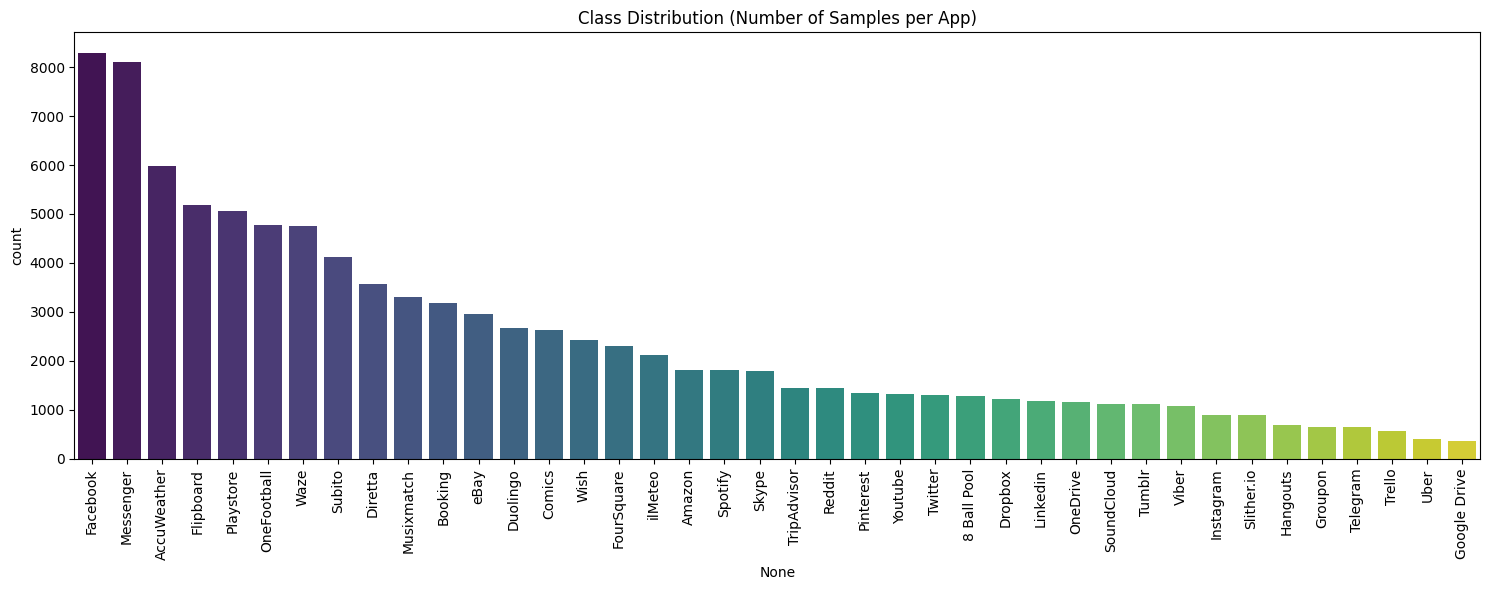

In [4]:
# Class Distribution
counts = Counter(y_raw)
df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).sort_values('count', ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')
plt.xticks(rotation=90)
plt.title("Class Distribution (Number of Samples per App)")
plt.tight_layout()
plt.show()

First split: 85% Train+Val, 15% Test and then Second split: Split the 85% into Train (70% total) and Val (15% total)

Train shape: (67896, 36, 4) (70.0%)
Val shape:   (14553, 36, 4)   (15.0%)
Test shape:  (14550, 36, 4)  (15.0%)


C:\Users\Matte\AppData\Local\Temp\ipykernel_2544\3588963389.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')


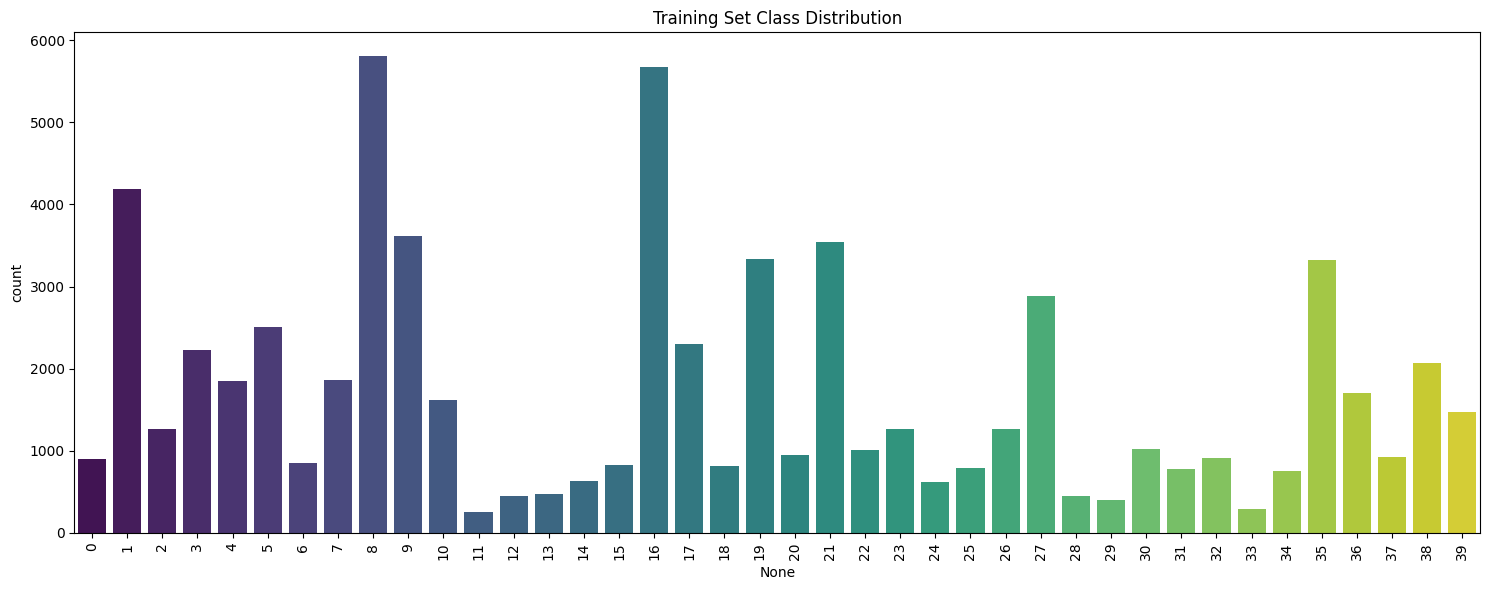

C:\Users\Matte\AppData\Local\Temp\ipykernel_2544\3588963389.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')


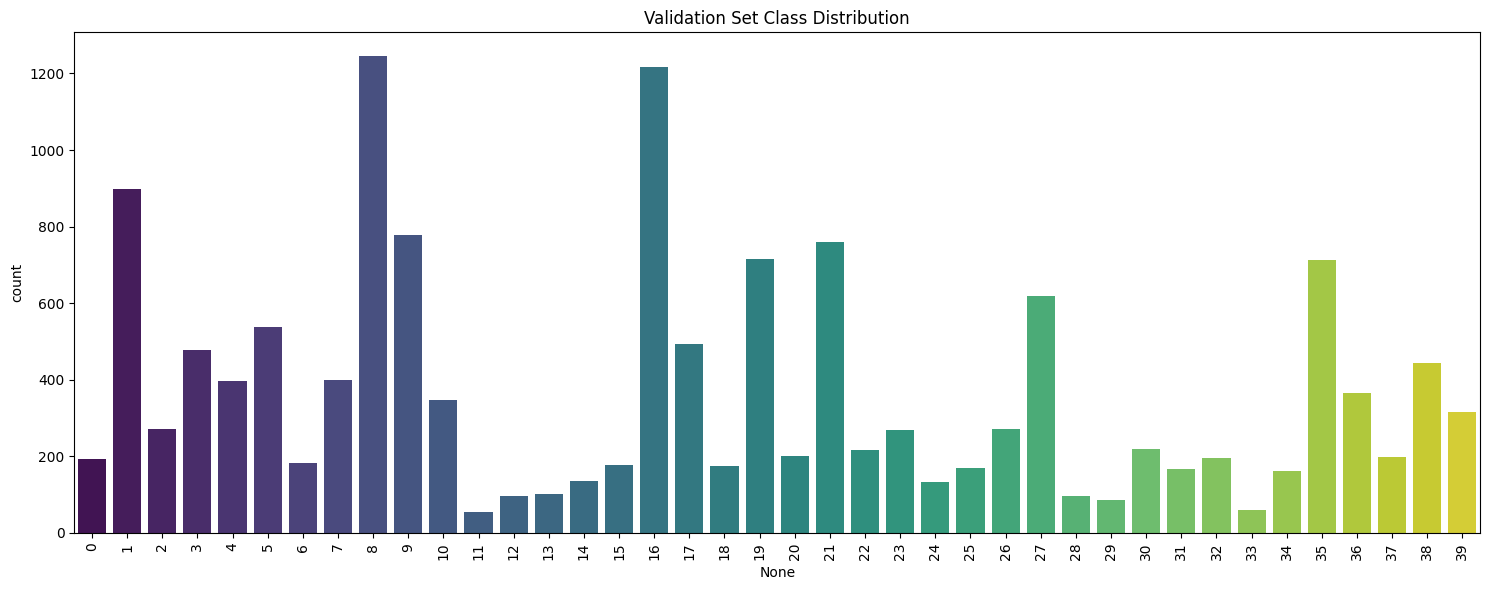

C:\Users\Matte\AppData\Local\Temp\ipykernel_2544\3588963389.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')


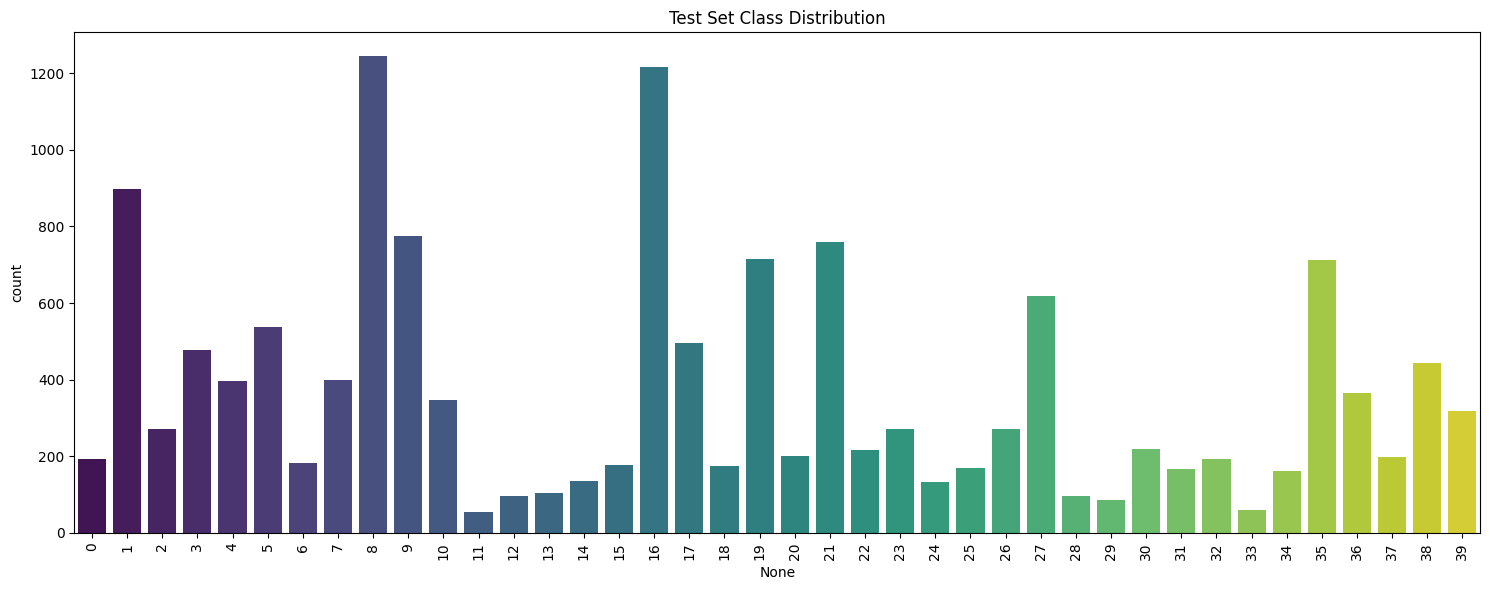

In [5]:
# First split: 85% Train+Val, 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y_encoded, test_size=0.15, stratify=y_encoded, random_state=2025)

# Second split: Split the 85% into Train (70% total) and Val (15% total)
# 15 / 85 ~= 0.1765
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=2025)

print(f"Train shape: {X_train.shape} ({len(X_train)/len(X_raw):.1%})")
print(f"Val shape:   {X_val.shape}   ({len(X_val)/len(X_raw):.1%})")
print(f"Test shape:  {X_test.shape}  ({len(X_test)/len(X_raw):.1%})")


def plot_class_distribution(y, title="Class Distribution"):
    counts = Counter(y)
    df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).sort_values('count', ascending=False)
    
    plt.figure(figsize=(15, 6))
    sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')
    plt.xticks(rotation=90)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_class_distribution(y_train, "Training Set Class Distribution")
plot_class_distribution(y_val, "Validation Set Class Distribution")
plot_class_distribution(y_test, "Test Set Class Distribution")


## Preprocessing
The dataset contains padding with `-1`. 
**Strategy**:
1.  **Label Encoding**: Convert string labels to integers.
2.  **Handling Padding & Normalization**:
    - Replace `-1` padding with `0` (Zero Padding is standard for CNNs).
    - Apply `log1p` (log(x+1)) to `Payload Length`, `TCP Window`, and `IAT` to compress their large dynamic range.
    - `Direction` is kept as is (or could be mapped, but -1, 0, 1 is fine for CNN).
3.  **Split**: Stratified Train/Test split (80/20).

In [6]:
def preprocess_data(X):
    """
    Handles padding and normalizes features.
    X shape: (N, 36, 4)
    Features: [DIR, PL, TCPWIN, IAT]
    """
    X_proc = X.copy().astype(np.float32)
    
    # Mask for padding (using PL at index 1)
    is_padding = (X_proc[:, :, 1] == -1)
    
    # Set all features to 0 where is_padding is True
    mask = np.repeat(is_padding[:, :, np.newaxis], 4, axis=2)
    X_proc[mask] = 0
    
    # Apply Log1p to PL (1), TCPWIN (2), IAT (3)
    X_proc[:, :, 1:] = np.log1p(np.maximum(X_proc[:, :, 1:], 0)) 
    
    return X_proc

print("Preprocessing data...")
X_train_proc = preprocess_data(X_train)
X_val_proc = preprocess_data(X_val)
X_test_proc = preprocess_data(X_test)

print("Preprocessing complete.")
print("Train shape:", X_train_proc.shape)
print("Val shape:", X_val_proc.shape)
print("Test shape:", X_test_proc.shape)

Preprocessing data...
Preprocessing complete.
Train shape: (67896, 36, 4)
Val shape: (14553, 36, 4)
Test shape: (14550, 36, 4)


## Dataset & DataLoader
PyTorch Dataset wrapper.

In [7]:
class MirageDataset(Dataset):
    def __init__(self, X, y):
        # X shape: (N, 36, 4)
        # CNN 1D expects (N, Channels, Length) -> (N, 4, 36)
        self.X = torch.FloatTensor(X).permute(0, 2, 1).to(DEVICE) # Remove to(DEVICE) if dataset doesn't fit in memory
        self.y = torch.LongTensor(y).to(DEVICE) # Remove to(DEVICE) if dataset doesn't fit in memory
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MirageDataset(X_train_proc, y_train)
val_dataset = MirageDataset(X_val_proc, y_val)
test_dataset = MirageDataset(X_test_proc, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## Model Architecture (1D-CNN)
A 3-layer 1D-CNN designed to capture temporal patterns in the packet sequence.

In [8]:
class TrafficCNN(nn.Module):
    def __init__(self, num_classes):
        super(TrafficCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Input: (B, 4, 36)
            nn.Conv1d(4, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Global Average Pooling -> (B, 256, 1)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = TrafficCNN(NUM_CLASSES).to(DEVICE)
print(model)

TrafficCNN(
  (features): Sequential(
    (0): Conv1d(4, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=40, bias=True)
  )
)


## Training Setup
Using **Class Weights** to handle imbalance and **OneCycleLR** for efficient convergence.

In [9]:
# Calculate Class Weights
class_counts = Counter(y_train)
total_samples = sum(class_counts.values())
weights = []
for i in range(NUM_CLASSES):
    count = class_counts.get(i, 0)
    if count > 0:
        weights.append(total_samples / (NUM_CLASSES * count))
    else:
        weights.append(1.0)
        
class_weights = torch.FloatTensor(weights).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LEARNING_RATE, steps_per_epoch=len(train_loader), epochs=EPOCHS)

## Training Loop

In [10]:
def train_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        # inputs, labels = inputs.to(DEVICE), labels.to(DEVICE) # Remove comment if dataset does't fit into memory
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            # inputs, labels = inputs.to(DEVICE), labels.to(DEVICE) # Remove comment if dataset does't fit into memory
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / len(loader), 100. * correct / total

print("Starting training...")
start_time = time.time()

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
patience_counter = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")
    
    # Checkpointing and Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        # torch.save(model.state_dict(), "best_model.pth")
        patience_counter = 0
        print(f"  -> Validation loss improved. Model saved.")
    else:
        patience_counter += 1
        print(f"  -> No improvement. Patience: {patience_counter}/{PATIENCE}")
        
    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes.")

Starting training...
Epoch [1/100] | Train Loss: 3.5987 Acc: 4.79% | Val Loss: 3.4955 Acc: 8.07%
  -> Validation loss improved. Model saved.
Epoch [2/100] | Train Loss: 3.4615 Acc: 7.75% | Val Loss: 3.3552 Acc: 12.93%
  -> Validation loss improved. Model saved.
Epoch [3/100] | Train Loss: 3.3506 Acc: 9.79% | Val Loss: 3.2276 Acc: 14.51%
  -> Validation loss improved. Model saved.
Epoch [4/100] | Train Loss: 3.2481 Acc: 11.77% | Val Loss: 3.1066 Acc: 17.17%
  -> Validation loss improved. Model saved.
Epoch [5/100] | Train Loss: 3.1482 Acc: 13.91% | Val Loss: 2.9921 Acc: 18.20%
  -> Validation loss improved. Model saved.
Epoch [6/100] | Train Loss: 3.0562 Acc: 16.20% | Val Loss: 2.8858 Acc: 19.86%
  -> Validation loss improved. Model saved.
Epoch [7/100] | Train Loss: 2.9619 Acc: 18.68% | Val Loss: 2.7832 Acc: 23.27%
  -> Validation loss improved. Model saved.
Epoch [8/100] | Train Loss: 2.8632 Acc: 21.54% | Val Loss: 2.6788 Acc: 26.03%
  -> Validation loss improved. Model saved.
Epoch [

Saving best model based on validation loss

In [11]:
print("Loading best model...")
model.load_state_dict(best_model_wts)

torch.save(model.state_dict(), "mirage19_model.pth")
print("Model saved to mirage19_model.pth")

with open("training_history.pkl", "wb") as f:
    pickle.dump(history, f)
print("Training history saved to training_history.pkl")

Loading best model...
Model saved to mirage19_model.pth
Training history saved to training_history.pkl


## Evaluation & Visualization

(Optional) Load a pre-trained model

In [12]:
# weights = torch.load("models/conv1d_B128_100E/mirage19_model.pth")
# model.load_state_dict(weights)
# print('Model loaded')
# # Load history in pickle format
# with open("models/conv1d_B128_100E/training_history.pkl", "rb") as f:
#     history = pickle.load(f)
# print('History loaded')

Test error and accuracy

In [13]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Test Loss: 0.9026 | Test Acc: 69.29%


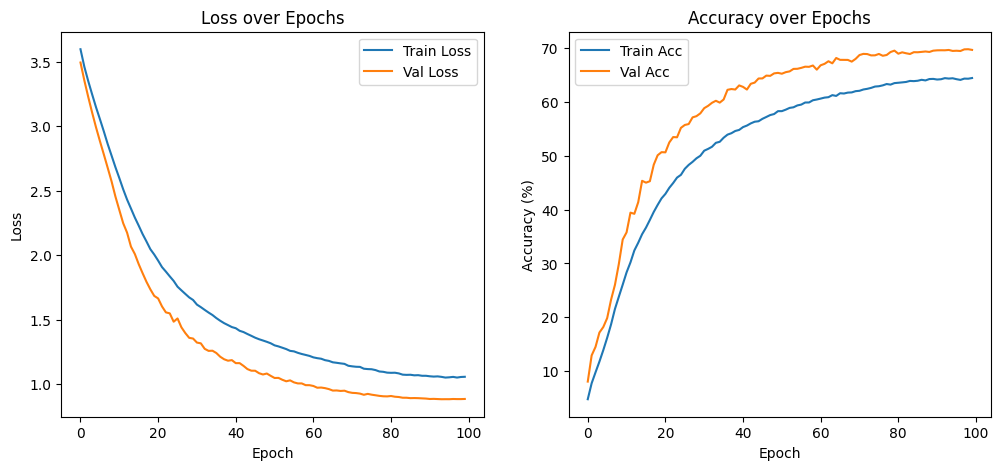

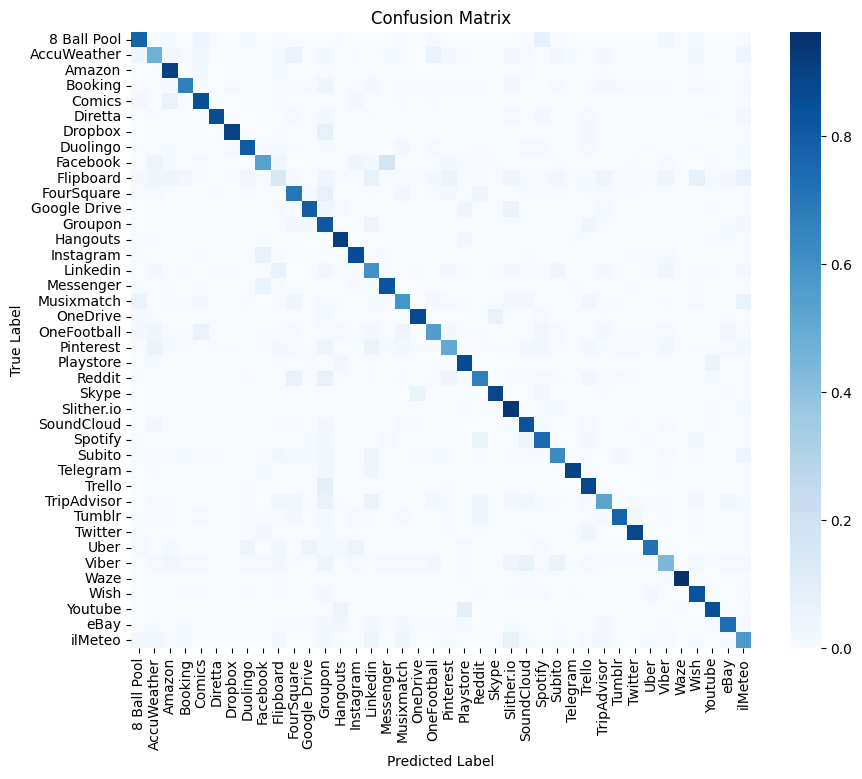

Classification Report:
              precision    recall  f1-score   support

 8 Ball Pool       0.50      0.78      0.61       192
 AccuWeather       0.68      0.47      0.56       898
      Amazon       0.63      0.90      0.75       272
     Booking       0.81      0.67      0.73       477
      Comics       0.70      0.85      0.77       396
     Diretta       0.95      0.85      0.90       537
     Dropbox       0.89      0.90      0.89       182
    Duolingo       0.86      0.80      0.83       399
    Facebook       0.85      0.54      0.66      1244
   Flipboard       0.38      0.14      0.21       776
  FourSquare       0.60      0.70      0.65       346
Google Drive       0.49      0.80      0.61        54
     Groupon       0.22      0.81      0.35        97
    Hangouts       0.54      0.91      0.68       103
   Instagram       0.53      0.86      0.65       136
    Linkedin       0.32      0.60      0.42       177
   Messenger       0.80      0.83      0.81      1216
  Mu

In [14]:
# Plot Training Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.show()

# Confusion Matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        # inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy()) # Replace with all_labels.extend(labels.numpy()) if using CPU

cm = confusion_matrix(all_labels, all_preds, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))